# Sigmoid neuron from scratch

## Objective

In this notebook, we will implement and train a single sigmoid neuron using NumPy. The model has two inputs, one output, and no hidden layer:

$$
z = \mathbf{X}\mathbf{w} + b,
\qquad
\hat{\mathbf{y}} = \sigma(z),
\qquad
\sigma(z)=\frac{1}{1+e^{-z}}.
$$

We will train the neuron on the **OR** truth table. OR is linearly separable, so a single neuron should be capable of learning an appropriate decision boundary.

## What "from scratch" means

NumPy will provide arrays and numerical operations, but it will not perform the learning for us. We will explicitly implement:

- the model parameters $\mathbf{w}$ and $b$;
- the forward pass;
- binary cross-entropy loss;
- the analytical gradients;
- gradient-descent parameter updates.

The implementation will be successful if the loss decreases and the trained neuron correctly classifies all four OR inputs.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

## OR training data

$$
y = x_1 \lor x_2
$$

The dataset contains all four possible combinations of two binary inputs.

In [2]:
X = np.array([[0.0, 0.0], [0.0, 1.0], [1.0, 0.0], [1.0, 1.0]])
y = np.array([[0.0], [1.0], [1.0], [1.0]])

In [3]:
display(X)
print("")
display(y)

array([[0., 0.],
       [0., 1.],
       [1., 0.],
       [1., 1.]])

array([[0.],
       [1.],
       [1.],
       [1.]])

## Sigmoid activation function

$$
\sigma(z)=\frac{1}{1+e^{-z}}
$$

The sigmoid maps any real-valued pre-activation to the interval $(0,1)$.

In [4]:
def sigmoid(z):
    return 1.0 / (1.0 + np.exp(-z))

In [5]:
z_test = np.array([-2.0, 0.0, 2.0])

sigmoid(z_test)

array([0.11920292, 0.5       , 0.88079708])

## Forward propagation

$$
\mathbf z=\mathbf X\mathbf w+b,
\qquad
\hat{\mathbf y}=\sigma(\mathbf z)
$$

In [6]:
w = np.zeros((2, 1))
b = 0.0

z = np.matmul(X, w) + b

y_hat = sigmoid(z)

## Binary cross-entropy loss

$$
J=-\frac{1}{N}\sum_{i=1}^{N}\left[y_i\log(\hat y_i)+(1-y_i)\log(1-\hat y_i)\right]
$$

In [7]:
def binary_cross_entropy(y_true, y_pred):
    eps = 1e-15
    y_pred_clip = y_pred.clip(eps, 1 - eps)

    loss = -( y_true * np.log(y_pred_clip) + (1.0 - y_true) * np.log(1.0 - y_pred_clip))
    return np.mean(loss)

In [8]:
display(binary_cross_entropy(y, y_hat))

np.float64(0.6931471805599453)

## Backpropagation: analytical gradients

For one training example $i$,

$$
z_i=\mathbf x_i^{\mathsf T}\mathbf w+b,
\qquad
\hat y_i=\sigma(z_i),
\qquad
\mathcal L_i=-\left[y_i\log(\hat y_i)+(1-y_i)\log(1-\hat y_i)\right].
$$

Differentiate the loss and the sigmoid:

$$
\frac{\partial\mathcal L_i}{\partial\hat y_i}
=-\frac{y_i}{\hat y_i}+\frac{1-y_i}{1-\hat y_i}
=\frac{\hat y_i-y_i}{\hat y_i(1-\hat y_i)},
\qquad
\frac{\partial\hat y_i}{\partial z_i}
=\hat y_i(1-\hat y_i).
$$

The chain rule therefore gives the useful cancellation

$$
\frac{\partial\mathcal L_i}{\partial z_i}
=\frac{\partial\mathcal L_i}{\partial\hat y_i}
 \frac{\partial\hat y_i}{\partial z_i}
=\hat y_i-y_i
=e_i.
$$

Since $\partial z_i/\partial\mathbf w=\mathbf x_i$ and $\partial z_i/\partial b=1$, averaging the per-example gradients yields

$$
\mathbf e=\hat{\mathbf y}-\mathbf y,
\qquad
\boxed{\frac{\partial J}{\partial\mathbf w}=\frac{1}{N}\mathbf X^{\mathsf T}\mathbf e},
\qquad
\boxed{\frac{\partial J}{\partial b}=\frac{1}{N}\sum_{i=1}^{N}e_i}.
$$

In [9]:
def gradient(X, y, y_hat):
    error = y_hat - y
    N = X.shape[0]
    dw = (1.0 / N) * np.matmul(X.T, error)
    db = np.mean(error)

    return dw, db

In [10]:
dw, db = gradient(X, y, y_hat)

## Gradient-descent update

$$
\mathbf w\leftarrow\mathbf w-\eta\frac{\partial J}{\partial\mathbf w},
\qquad
b\leftarrow b-\eta\frac{\partial J}{\partial b}
$$

In [11]:
dw, db = gradient(X, y, y_hat)

loss_before = binary_cross_entropy(y, y_hat)

learning_rate = 0.1

updated_w = w - learning_rate * dw
updated_b = b - learning_rate * db

updated_z = np.matmul(X, updated_w) + updated_b

updated_y_hat = sigmoid(updated_z)

loss_after = binary_cross_entropy(y, updated_y_hat)

In [12]:
display(updated_w)
display(updated_b)
display(updated_y_hat)
display(loss_before)
display(loss_after)

array([[0.025],
       [0.025]])

np.float64(0.025)

array([[0.50624967],
       [0.5124974 ],
       [0.5124974 ],
       [0.51874122]])

np.float64(0.6931471805599453)

np.float64(0.6747486850947232)

## Training loop

Repeat forward propagation, loss evaluation, backpropagation, and the parameter update:

$$
\boldsymbol\theta^{(t+1)}=\boldsymbol\theta^{(t)}-\eta\nabla_{\boldsymbol\theta}J\!\left(\boldsymbol\theta^{(t)}\right)
$$

In [13]:
learning_rate = 0.1
num_epochs = 2000
w = np.zeros((2, 1))
b = 0.0
loss_history = []

for epoch in range(num_epochs):
    z = np.matmul(X, w) + b
    y_hat = sigmoid(z)
    loss = binary_cross_entropy(y, y_hat)
    loss_history.append(loss)
    dw, db = gradient(X, y, y_hat)
    w = w - learning_rate * dw
    b = b - learning_rate * db

z = np.matmul(X, w) + b
y_hat = sigmoid(z)

display(w)
display(b)
print("")
display(y_hat)
print("")

final_loss = binary_cross_entropy(y, y_hat)

display(final_loss)
print("")

predictions = np.where(y_hat >= 0.5, 1, 0)

display(predictions)

array([[5.36050042],
       [5.36050042]])

np.float64(-2.183598467810479)

array([[0.10123305],
       [0.95995574],
       [0.95995574],
       [0.99980404]])

np.float64(0.047165920560068)

array([[0],
       [1],
       [1],
       [1]])

## Learning curve

$$
J^{(t)}=\mathcal L\!\left(\mathbf y, f(\mathbf X;\boldsymbol\theta^{(t)})\right)
$$

Plot loss against epoch to verify that optimization progresses.

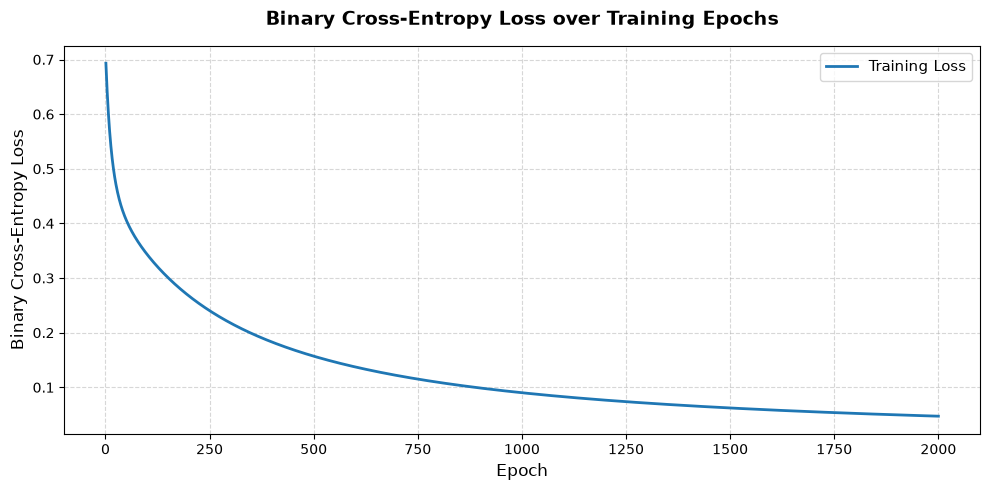

In [14]:
plt.figure(figsize=(10, 5))
epochs = range(1, len(loss_history) + 1)

plt.plot(epochs, loss_history, color="#1f77b4", linewidth=2, label="Training Loss")

plt.title("Binary Cross-Entropy Loss over Training Epochs", fontsize=14, fontweight="bold", pad=15)
plt.xlabel("Epoch", fontsize=12)
plt.ylabel("Binary Cross-Entropy Loss", fontsize=12)

plt.grid(True, linestyle="--", alpha=0.5)

plt.legend(fontsize=11)
plt.tight_layout()

plt.show()

## Learned decision boundary

At the classification threshold $\hat y=0.5$, the logit is zero:

$$
w_1x_1+w_2x_2+b=0
\qquad\Longrightarrow\qquad
x_2=-\frac{w_1x_1+b}{w_2}.
$$

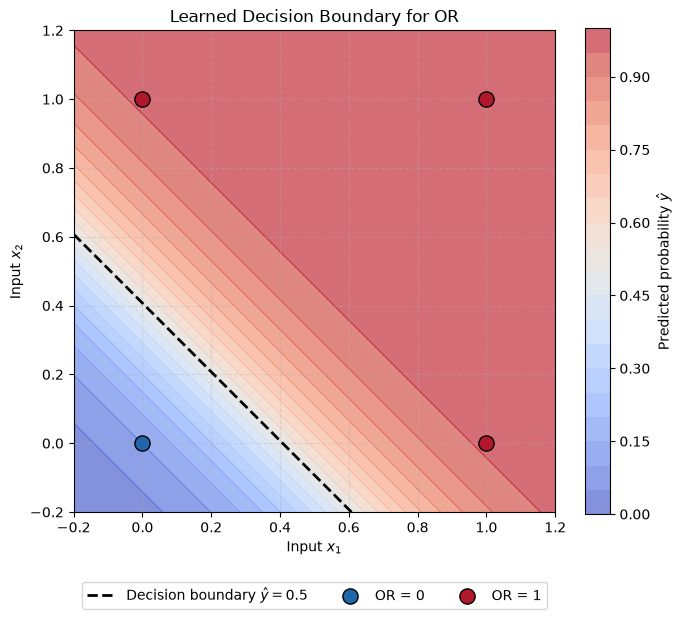

In [15]:
x1_values = np.linspace(-0.2, 1.2, 300)
x2_values = np.linspace(-0.2, 1.2, 300)
x1_grid, x2_grid = np.meshgrid(x1_values, x2_values)
grid_points = np.column_stack((x1_grid.ravel(), x2_grid.ravel()))
probability_grid = sigmoid(grid_points @ w + b).reshape(x1_grid.shape)

fig, ax = plt.subplots(figsize=(7, 6))
probability_map = ax.contourf(
    x1_grid,
    x2_grid,
    probability_grid,
    levels=np.linspace(0.0, 1.0, 21),
    cmap="coolwarm",
    alpha=0.65,
)
fig.colorbar(probability_map, ax=ax, label=r"Predicted probability $\hat{y}$")

x1_boundary = np.linspace(-0.2, 1.2, 200)
x2_boundary = -(w[0, 0] * x1_boundary + b) / w[1, 0]
ax.plot(
    x1_boundary,
    x2_boundary,
    "k--",
    linewidth=2,
    label=r"Decision boundary $\hat{y}=0.5$",
)

negative = y.ravel() == 0
positive = y.ravel() == 1
ax.scatter(
    X[negative, 0], X[negative, 1],
    s=120, color="#2166ac", edgecolor="black", label="OR = 0", zorder=3,
)
ax.scatter(
    X[positive, 0], X[positive, 1],
    s=120, color="#b2182b", edgecolor="black", label="OR = 1", zorder=3,
)

ax.set(
    xlim=(-0.2, 1.2),
    ylim=(-0.2, 1.2),
    xlabel=r"Input $x_1$",
    ylabel=r"Input $x_2$",
    title="Learned Decision Boundary for OR",
)
ax.set_aspect("equal")
ax.grid(True, linestyle="--", alpha=0.35)
ax.legend(loc="upper center", bbox_to_anchor=(0.5, -0.13), ncol=3)
plt.tight_layout()
plt.show()